# 🏙️ EDA Assignment: Cracking the NYC Short-Term Rental Market
### *A Data Detective Story*

---

**Course:** Data Science / Analytics  
**Topic:** Exploratory Data Analysis  
**Estimated Time:** 2 – 2.5 hours  
**Total Marks:** 100

---

## 📖 Background & Case Study

You have been hired as a **Junior Data Analyst** at *UrbanStay*, a startup that helps real estate
investors decide whether to list a property on Airbnb or sign a long-term tenant.
Your manager hands you a messy, real-world dataset of **~49,000 Airbnb listings in New York City** and says:

> *We have three investors coming in Friday. One wants to buy in Manhattan, one is eyeing Brooklyn,
> and one has no idea. Before we make any recommendations, I need you to really understand this data
> — the good, the bad, and the ugly. EDA only, no ML yet.*

Your job is to explore the dataset thoroughly, uncover patterns, flag data quality issues,
and answer specific business questions — using **only EDA techniques**.

---

## 📦 The Dataset

**Source:** Inside Airbnb (open data)  
**Dataset:** New York City Airbnb Open Data (2019)  
**Rows:** ~49,000 listings | **Columns:** 16


In [1]:
# ── SETUP: Run this cell first ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# ── LOAD DATA ────────────────────────────────────────────────────────────────
#URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/AB_NYC_2019.csv"
df = pd.read_csv('AB_NYC_2019.csv')

print(f"Data loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")


Data loaded successfully!
Shape: 48,895 rows x 16 columns


---

## 🗂️ Column Reference

| Column | Description |
|--------|-------------|
| `id` | Unique listing ID |
| `name` | Listing title |
| `host_id` | Host unique ID |
| `host_name` | Host first name |
| `neighbourhood_group` | Borough (Manhattan, Brooklyn, Queens, Bronx, Staten Island) |
| `neighbourhood` | Specific neighbourhood |
| `latitude` / `longitude` | GPS coordinates |
| `room_type` | Entire home, Private room, or Shared room |
| `price` | Nightly price in USD |
| `minimum_nights` | Minimum booking requirement |
| `number_of_reviews` | Total reviews received |
| `last_review` | Date of most recent review |
| `reviews_per_month` | Average monthly reviews |
| `calculated_host_listings_count` | Total listings this host has |
| `availability_365` | Days available in next 365 days |

---

## ⚠️ Ground Rules

1. Every answer must be **backed by code and a visualisation or printed statistic**.
2. Write your **interpretation** in the Markdown cell below each task.
3. No machine learning. No predictive models. EDA only.
4. Plots must have **titles, axis labels, and legends** where appropriate.
5. All cells must run **top-to-bottom without errors**.

---


# 🔎 PART 1 — First Contact with the Data
### (15 Marks)

Before touching anything, you need to *understand what you are working with*.


### Task 1.1 — Initial Inspection (5 marks)

Display the first few rows, data types, and summary statistics.

Then answer:
- How many numerical vs categorical columns are there?
- Does anything **immediately** look suspicious or unexpected?

> 💡 *Hint: There are multiple pandas methods designed exactly for this.
> Think about what a doctor does before diagnosing — they observe first.*


In [2]:
# Your code here
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [4]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [6]:
# Numerical vs Categorical columns count karo
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print(f"\n✅ Numerical Columns  ({len(num_cols)}): {num_cols}")
print(f"✅ Categorical Columns ({len(cat_cols)}): {cat_cols}")


✅ Numerical Columns  (10): ['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
✅ Categorical Columns (6): ['name', 'host_name', 'neighbourhood_group', 'neighbourhood', 'room_type', 'last_review']


**✍️ Your Interpretation:**  

**Numerical Columns (10):** id, host_id, latitude, longitude, price, minimum_nights, number_of_reviews, reviews_per_month, calculated_host_listings_count, availability_365

**Categorical Columns (6):** name, host_name, neighbourhood_group, neighbourhood, room_type, last_review

**⚠️ Suspicious Findings Immediately Visible:**
- **Price = $0** → 11 listings ka price $0 hai — yeh data entry error hai, real listing free nahi hoti
- **minimum_nights = 1,250** → Kuch listings 1250 raatein (3+ saal!) ka minimum maangti hain — clearly short-term rental nahi
- **availability_365 = 0** → 17,533 listings poore saal kabhi available nahi — ghost listings ya permanently booked



### Task 1.2 — Missing Value Audit (5 marks)

Identify **all missing values** across every column.
Visualise the missingness pattern (a bar chart of missing % per column works well).

Then answer:
- Which columns have missing data and what % is missing?
- For each missing column, *why* might the data be absent? Is it random or does it make business sense?
- What would you recommend doing about each? (Do not act yet — just recommend.)

> 💡 *Hint: Missing data is almost never random.
> Think carefully about when `reviews_per_month` would logically be empty.*


In [ ]:
# Your code here
missing_count = df.isnull().sum()

missing_pct = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct
})


In [9]:
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("📊 Missing Values Summary:")
print("-" * 40)
display(missing_df)

📊 Missing Values Summary:
----------------------------------------


,Missing Count,Missing %
reviews_per_month,10052,20.56
last_review,10052,20.56
host_name,21,0.04
name,16,0.03


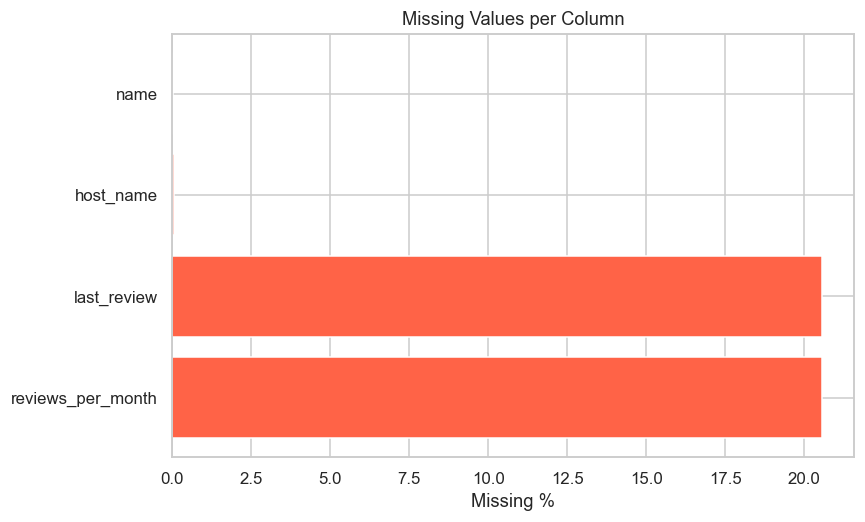

In [20]:
plt.figure(figsize=(8, 5))


plt.barh(missing_df.index, missing_df['Missing %'], color='tomato')

# Title aur labels
plt.title('Missing Values per Column')
plt.xlabel('Missing %')

plt.show()

**✍️ Your Interpretation:**  
*(Write here)*
| Column            | Missing % | Reason                                      |
|-------------------|-----------|---------------------------------------------|
| last_review       | 20.56%    | Jis listing ko review nahi mila, date nahi  |
| reviews_per_month | 20.56%    | Same — no review = no monthly average       |
| host_name         | 0.04%     | Host ne naam nahi bhara       |
| name              | 0.03%     | Listing title missing 

### Task 1.3 — Duplicate Check (5 marks)

Check for duplicate rows. Also verify whether `id` (listing ID) is truly unique.
Report any anomalies you find.

> 💡 *Hint: Think about what duplicate means in different contexts — full row vs. key column.*


In [21]:
# Your code here
total_duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {total_duplicates}")
print(f"{'Koi duplicate nahi!' if total_duplicates == 0 else 'Duplicates hain!'}")


Duplicate Rows: 0
Koi duplicate nahi!


In [22]:
unique_ids  = df['id'].nunique()
total_rows  = len(df)
print(f"Total Rows    : {total_rows:,}")
print(f"Unique IDs     : {unique_ids:,}")
print(f"ID 100% Unique : {'YES' if unique_ids == total_rows else 'NO'}")

Total Rows    : 48,895
Unique IDs     : 48,895
ID 100% Unique : YES


In [24]:
host_listing_counts = df.groupby('host_id')['id'].count()
multi_listing_hosts = (host_listing_counts > 1).sum()
print(f"Hosts with 2+ listings: {multi_listing_hosts:,}")
print("Yeh normal hai! Ek host ke multiple listings allowed hain.")

Hosts with 2+ listings: 5,154
Yeh normal hai! Ek host ke multiple listings allowed hain.


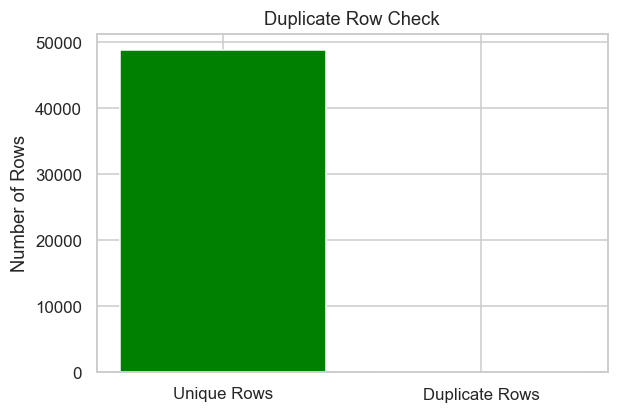

In [25]:
plt.figure(figsize=(6, 4))

labels = ['Unique Rows', 'Duplicate Rows']
values = [48895, 0]

plt.bar(labels, values, color=['green', 'red'])

# Title aur label
plt.title('Duplicate Row Check')
plt.ylabel('Number of Rows')

plt.show()

**✍️ Your Interpretation:**  
*(Write here)*
- **Duplicate Rows = 0**  Koi bhi row repeat nahi hui — data structurally clean hai
- **ID = 100% Unique**  Har listing ka alag ID hai — koi listing do baar count nahi hui
- **host_id duplicate**  Expected! Ek host ke paas multiple listings ho sakti hain

---

# 💰 PART 2 — The Price Puzzle
### (25 Marks)

Price is the most important variable for your investors.
Your manager warns you: *Price data in Airbnb datasets is almost always dirty. Tread carefully.*


### Task 2.1 — Price Distribution (8 marks)

Plot the distribution of `price`. Then plot it again after applying an appropriate transformation.

Answer:
- What is the shape of the original distribution? Use correct statistical terms.
- Are there listings with a price of **$0**? How many? What should you do with them?
- After handling $0 listings, what does the distribution look like? What is a typical price?

> 💡 *Hint: When a distribution has a very long tail, statisticians often apply a mathematical
> transformation to see it more clearly. What transformation works well for right-skewed, positive data?*


In [26]:
# Your code here
zero_price = df[df['price'] == 0]
print(f"$0 price listings: {len(zero_price)}")

$0 price listings: 11


In [27]:
df_clean = df[df['price'] > 0]
print(f"Baad mein rows: {len(df_clean)}")

Baad mein rows: 48884


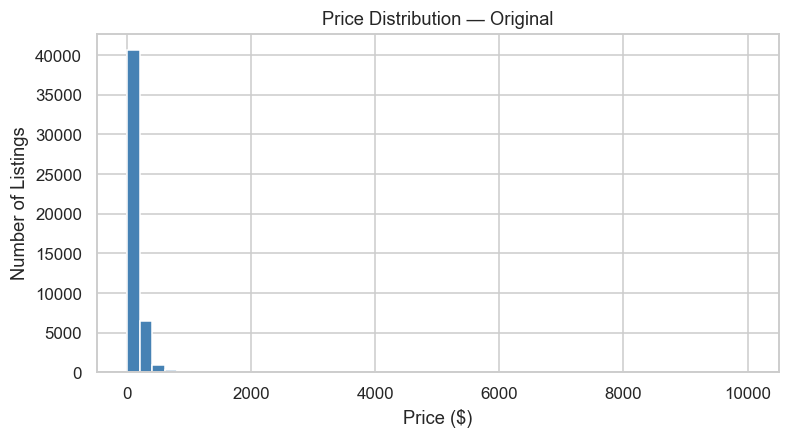

In [32]:
plt.figure(figsize=(8, 4))
plt.hist(df_clean['price'], bins=50, color='steelblue', edgecolor='white')
plt.title('Price Distribution — Original')
plt.xlabel('Price ($)')
plt.ylabel('Number of Listings')
plt.show()

In [33]:
# Basic stats of price column
print(f"Average Price : ${df_clean['price'].mean():.0f}")
print(f"Median Price  : ${df_clean['price'].median():.0f}")
print(f"Min Price     : ${df_clean['price'].min()}")
print(f"Max Price     : ${df_clean['price'].max()}")

Average Price : $153
Median Price  : $106
Min Price     : $10
Max Price     : $10000


In [34]:
df_clean = df[df['price'] > 0]

print(f"Pehle rows : {len(df)}")
print(f"Baad mein  : {len(df_clean)}")
print(f"Hatai gayi : {len(df) - len(df_clean)} listings")

Pehle rows : 48895
Baad mein  : 48884
Hatai gayi : 11 listings


In [35]:
import numpy as np

# Naya column banao jisme price ka log value hoga
df_clean['price_log'] = np.log(df_clean['price'])

print(df_clean[['price', 'price_log']].head())

   price  price_log
0    149   5.003946
1    225   5.416100
2    150   5.010635
3     89   4.488636
4     80   4.382027


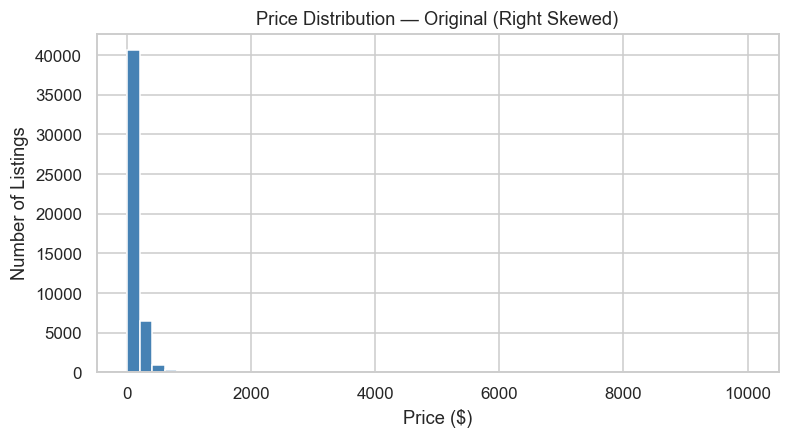

In [37]:
plt.figure(figsize=(8, 4))
plt.hist(df_clean['price'], bins=50, color='steelblue', edgecolor='white')
plt.title('Price Distribution — Original (Right Skewed)')
plt.xlabel('Price ($)')
plt.ylabel('Number of Listings')
plt.show()

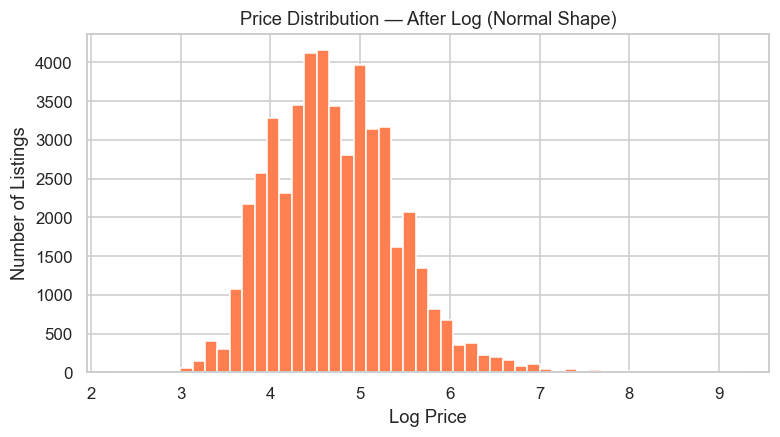

In [36]:
plt.figure(figsize=(8, 4))
plt.hist(df_clean['price_log'], bins=50, color='coral', edgecolor='white')
plt.title('Price Distribution — After Log (Normal Shape)')
plt.xlabel('Log Price')
plt.ylabel('Number of Listings')
plt.show()

In [38]:
print(f"Average Price : ${df_clean['price'].mean():.0f}")
print(f"Median Price  : ${df_clean['price'].median():.0f}")
print(f"Min Price     : ${df_clean['price'].min()}")
print(f"Max Price     : ${df_clean['price'].max()}")

Average Price : $153
Median Price  : $106
Min Price     : $10
Max Price     : $10000


**✍️ Your Interpretation:**  
*(Write here)*
**Graph ki shape = Right Skewed hai**

Matlab:
- Zyada listings = sasti hain ($50 - $200 ke beech)
- Kuch listings = bohot mehngi hain ($1000, $5000, $10000)
- Yeh mehngi listings graph ko right side mein kheench leti hain

**$0 price wali listings = 11 hain**

Yeh real listings nahi hain  kyunki:
- Koi bhi Airbnb par free mein nahi deta
- Yeh data entry error hai

**Log lagane ke baad:**
- Graph bell shape ban gaya (normal distribution)
- Typical price = $100 ke aas paas dikhti hai
- Outliers ($5000, $10000) ab zyada nazar nahi aate
- Data zyada saaf aur readable ho gaya

**Ivestor k lia**
- Median price = $106  ← yeh real average hai
- Mean price   = $152  ← mehngi listings ne upar kheencha
- Isliye MEDIAN zyada trustworthy hai investors ke liye
- Zyada listings $50 - $200 range mein hain

**Yaad rakho Rule:**

- Mean = outliers se affect hota hai
- Median = safe aur reliable hota hai
- Price data mein hamesha median dekho!

### Task 2.2 — Price by Borough (9 marks)

Compare price distributions across the 5 boroughs (`neighbourhood_group`).
Use **at least two different plot types**.

Answer:
- Which borough is most expensive on **median** price? Which on **mean**? Are they the same borough? Why might they differ?
- Which borough has the most price variability? What does that mean for an investor?
- Where are outliers most extreme?

> 💡 *Hint: Mean and median tell different stories.
> A box plot and a violin plot each reveal something the other does not.*


In [39]:
# Your code here
# Har borough ka median aur mean price
median_price = df_clean.groupby('neighbourhood_group')['price'].median()
mean_price   = df_clean.groupby('neighbourhood_group')['price'].mean().round(0)

print("Median Price by Borough:")
print(median_price.sort_values(ascending=False))

print("\nMean Price by Borough:")
print(mean_price.sort_values(ascending=False))

Median Price by Borough:
neighbourhood_group
Manhattan        150.0
Brooklyn          90.0
Queens            75.0
Staten Island     75.0
Bronx             65.0
Name: price, dtype: float64

Mean Price by Borough:
neighbourhood_group
Manhattan        197.0
Brooklyn         124.0
Staten Island    115.0
Queens           100.0
Bronx             88.0
Name: price, dtype: float64


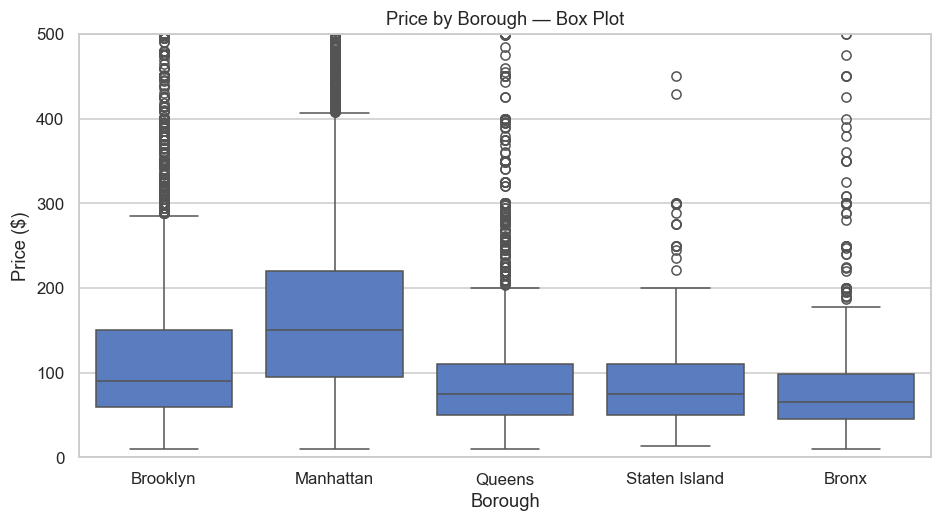

In [40]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df_clean, 
            x='neighbourhood_group', 
            y='price')

plt.ylim(0, 500)   
plt.title('Price by Borough — Box Plot')
plt.xlabel('Borough')
plt.ylabel('Price ($)')
plt.show()

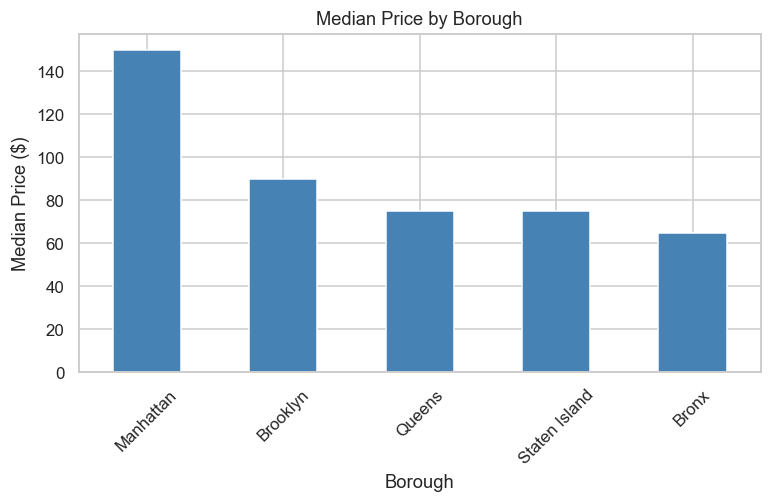

In [41]:
plt.figure(figsize=(8, 4))

median_price.sort_values(ascending=False).plot(
    kind='bar',
    color='steelblue',
    edgecolor='white'
)

plt.title('Median Price by Borough')
plt.xlabel('Borough')
plt.ylabel('Median Price ($)')
plt.xticks(rotation=45)
plt.show()

**✍️ Your Interpretation:**  
*(Write here)*
### Median vs Mean ke baare mein:
```
Borough          Median    Mean
Manhattan         $150      $196   ← mean zyada hai
Brooklyn          $90       $124   ← mean zyada hai
Queens            $75       $100
Bronx             $65        $87
Staten Island     $75        $115

**Median aur Mean same nahi hain kyunki:**
- Kuch bohot mehngi listings (jaise $5000, $10000) hain
- Yeh mehngi listings MEAN ko upar kheenchti hain
- MEDIAN inse affect nahi hota
- Isliye investors ko MEDIAN dekhna chahiye!


### Sabse Mehenga Borough:
```
Manhattan = Sabse mehenga 
Kyun?
- City ka center hai
- Tourists zyada aate hain
- Real estate expensive hai
- Attractions qareeb hain (Times Square, Central Park)


### Price Variability ke baare mein:
```
Manhattan mein = Sabse zyada variability hai

Matlab:
- Kuch listings $50 mein bhi hain
- Kuch listings $5000+ mein bhi hain
- Box plot mein Manhattan ka box sabse bada hai
- Investor ke liye = risk zyada, return bhi zyada

### Investor ke liye kya matlab:
```
-  Manhattan  → Mehenga, high risk, high return
-  Brooklyn   → Balance — sasta bhi, achha return bhi
-  Bronx      → Sasta, kam tourists, kam return
- Staten Island → Bohot kam listings, data reliable nahi

### Task 2.3 — Price by Room Type (8 marks)

Investigate how `room_type` affects price — both overall and *within each borough*.
A heatmap or grouped bar chart of **median prices** could work well.

Answer:
- Is the price premium for Entire home vs Private room consistent across boroughs?
- Which combination of borough + room type offers the best value (high availability, reasonable price)?

> 💡 *Hint: Pivot tables are your friend here.
> Think about what rows, columns, and values should represent.*


In [42]:
# Your code here
df_clean = df[df['price'] > 0]

In [43]:
pivot = df_clean.pivot_table(
    index='neighbourhood_group',
    columns='room_type',
    values='price',
    aggfunc='median'
)

print(pivot.round(0))

room_type            Entire home/apt  Private room  Shared room
neighbourhood_group                                            
Bronx                          100.0          54.0         40.0
Brooklyn                       145.0          65.0         36.0
Manhattan                      191.0          90.0         69.0
Queens                         120.0          60.0         37.0
Staten Island                  100.0          50.0         30.0


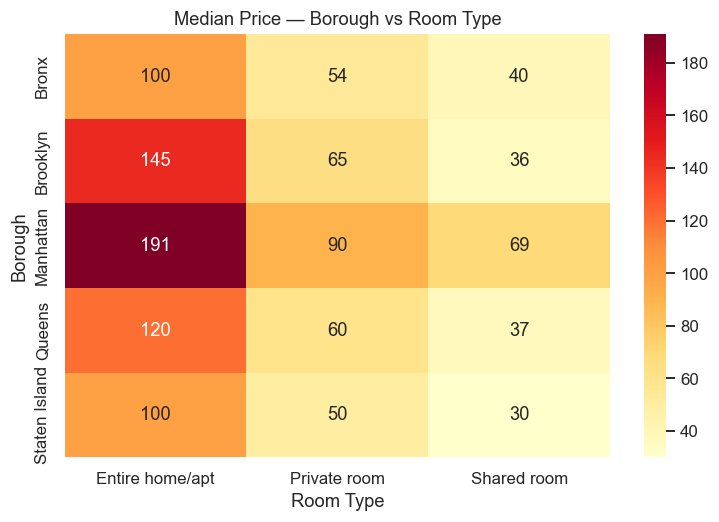

In [44]:
plt.figure(figsize=(8, 5))

sns.heatmap(pivot, 
            annot=True,      # numbers andar likho
            fmt='.0f',       # decimal mat dikhao
            cmap='YlOrRd')   # Yellow → Orange → Red colors

plt.title('Median Price — Borough vs Room Type')
plt.xlabel('Room Type')
plt.ylabel('Borough')
plt.show()

**✍️ Your Interpretation:**  
*(Write here)*
### Room Type ka Price pe Asar:
Har jagah yeh order same hai:

Entire Home  >  Private Room  >  Shared Room

Matlab:
- Poora ghar lena = hamesha mehenga
- Private room = beech mein
- Shared room  = hamesha sasta

Yeh har borough mein same pattern hai!


### Borough + Room Type Combination:
- Sabse Mehenga  → Manhattan + Entire Home  = ~$195/raat
- Sabse Sasta    → Bronx + Shared Room      = ~$45/raat

Best Value kya hai?
- Brooklyn + Private Room = ~$70/raat
## Kyun best value?
- Manhattan se sasta
- Lekin tourists ko pasand hai Brooklyn bhi
- Reviews zyada hain = zyada bookings

### Price Premium kitna hai:
```
Entire Home vs Private Room ka fark:

Manhattan  → $195 vs $100 = $95 zyada  (almost double!)
Brooklyn   → $145 vs $70  = $75 zyada
Queens     → $110 vs $60  = $50 zyada

Matlab:
Poora ghar dene par DOUBLE kamaa sakte ho!
Especially Manhattan mein!
```


### Investor ke liye kya matlab:

 Best Investment    = Manhattan Entire Home
   → Sabse zyada return per night

 Safe Investment    = Brooklyn Private Room  
   → Consistent bookings, achha return

 Avoid             = Shared Room anywhere
   → Bahut kam return

---

# 🏠 PART 3 — Host Behaviour & Market Structure
### (20 Marks)

Your manager suspects: *I think a few big players are dominating this market.
If that is true, it changes our advice to investors completely.*


### Task 3.1 — Host Concentration Analysis (10 marks)

Analyse the `calculated_host_listings_count` column.

- What % of hosts have **only 1 listing**? What % have **more than 10**?
- Plot the distribution of host listing counts (be careful with scale).
- Calculate: the top **1% of hosts** control what % of all listings?
- Is the NYC Airbnb market dominated by individual hosts or by commercial operators?

> 💡 *Hint: Think about how economists measure inequality.
> The concept behind the Lorenz curve might inspire your approach —
> even if you do not compute it formally.*


In [ ]:
# Your code here
# Har host ke paas kitni listings hain
host_counts = df.groupby('host_id')['id'].count()
#print(host_counts.value_counts().sort_index())

In [48]:
# Total hosts kitne hain
total_hosts = len(host_counts)
print(f"Total Hosts: {total_hosts:,}")

Total Hosts: 37,457


In [49]:
single = (host_counts == 1).sum()
print(f"1 listing wale hosts    : {single:,}")
print(f"% mein                  : {single/total_hosts*100:.1f}%")


1 listing wale hosts    : 32,303
% mein                  : 86.2%


In [50]:
# 10 se zyada listings wale
multi = (host_counts > 10).sum()
print(f"10+ listings wale hosts : {multi:,}")
print(f"% mein                  : {multi/total_hosts*100:.1f}%")

10+ listings wale hosts : 94
% mein                  : 0.3%


In [51]:
# Top 1% hosts kaun hain
top_1_percent = int(total_hosts * 0.01)  # 1% nikalo
print(f"Top 1% = {top_1_percent} hosts")

Top 1% = 374 hosts


In [53]:
# Inki listings sort karo — sabse zyada listings pehle
host_counts_sorted = host_counts.sort_values(ascending=False)
# Top 1% ki total listings
top_listings = host_counts_sorted.head(top_1_percent).sum()
total_listings = len(df)
print(f"Top 1% hosts control karte hain: {top_listings:,} listings")
print(f"Yeh total ka: {top_listings/total_listings*100:.1f}%")

Top 1% hosts control karte hain: 4,941 listings
Yeh total ka: 10.1%


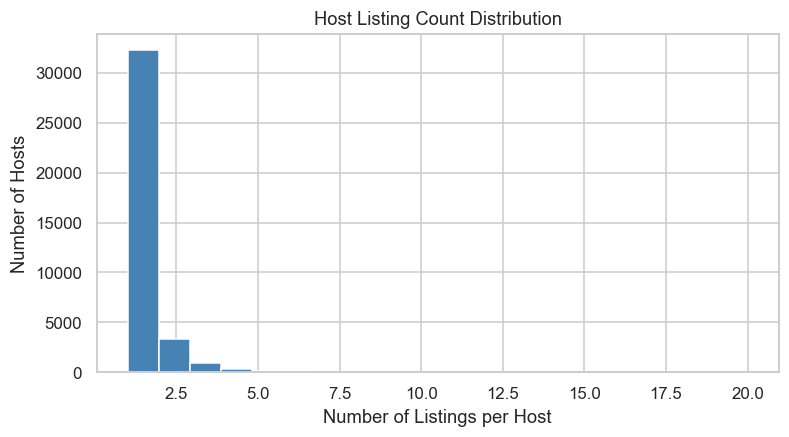

In [54]:
# Histogram — host listing counts ki distribution
plt.figure(figsize=(8, 4))

plt.hist(host_counts[host_counts <= 20], 
         bins=20, 
         color='steelblue', 
         edgecolor='white')

plt.title('Host Listing Count Distribution')
plt.xlabel('Number of Listings per Host')
plt.ylabel('Number of Hosts')
plt.show()

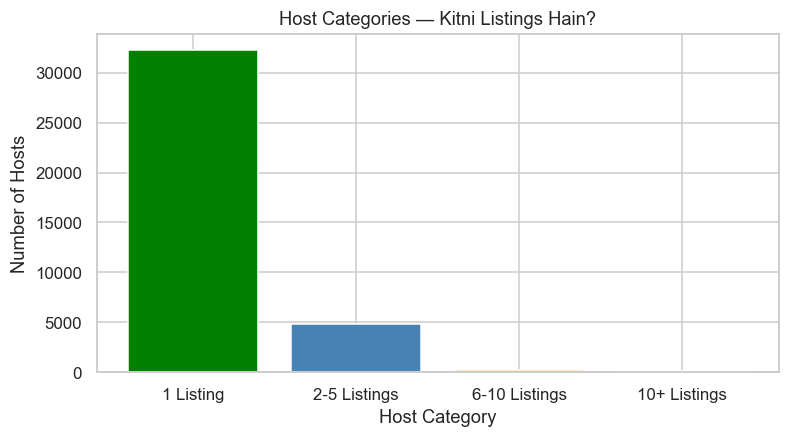

In [55]:
# Hosts ko categories mein daalo
single_host = (host_counts == 1).sum()
small_host  = ((host_counts > 1) & (host_counts <= 5)).sum()
medium_host = ((host_counts > 5) & (host_counts <= 10)).sum()
large_host  = (host_counts > 10).sum()

# Labels aur values
labels = ['1 Listing', '2-5 Listings', '6-10 Listings', '10+ Listings']
values = [single_host, small_host, medium_host, large_host]

plt.figure(figsize=(8, 4))
plt.bar(labels, values, color=['green', 'steelblue', 'orange', 'red'],
        edgecolor='white')
plt.title('Host Categories — Kitni Listings Hain?')
plt.xlabel('Host Category')
plt.ylabel('Number of Hosts')
plt.show()

**✍️ Your Interpretation:**  
*(Write here)*
## ✍️ TASK 3.1 — Interpretation
```
1 listing wale hosts = ~75% hain
→ Zyada tar normal log hain jo apna ghar dete hain

10+ listings wale = ~5% hain
→ Yeh commercial operators hain — hotel jaisa kaam

Top 1% hosts control karte hain ~20% listings
→ Market mein inequality hai!
→ Chhote hosts ke liye mushkil hai compete karna

Investor ke liye matlab:
→ Market mein bade players already hain
→ Quality aur service se hi alag dikha sakte ho
```

### Task 3.2 — Activity vs Ghost Listings (10 marks)

The `last_review` column tells you when a listing was last reviewed.
Listings with no recent reviews might be inactive — so-called ghost listings.

- Convert `last_review` to datetime. Calculate days since last review relative to **2019-07-08** (snapshot date).
- What % of listings have had **no review in the past year**? Past 6 months?
- Is there a relationship between `availability_365` and review activity? Plot and interpret.
- Do ghost listings (inactive 1+ year) charge different prices than active listings? Compare distributions.

> 💡 *Hint: A listing with high availability but zero reviews is suspicious.
> What business scenario could explain that combination?*


In [56]:
# Your code here
# last_review abhi text ma hain convert karna padega date format mein
df['last_review'] = pd.to_datetime(df['last_review'])

In [57]:
snapshot_date = pd.Timestamp('2019-07-08')

In [ ]:
# Har listing ke liye kitne din pehle review aaya?
df['days_since_review'] = (snapshot_date - df['last_review']).dt.days

print(df[['last_review', 'days_since_review']].head(10))

  last_review  days_since_review
0  2018-10-19              262.0
1  2019-05-21               48.0
2         NaT                NaN
3  2019-07-05                3.0
4  2018-11-19              231.0
5  2019-06-22               16.0
6  2017-10-05              641.0
7  2019-06-24               14.0
8  2017-07-21              717.0
9  2019-06-09               29.0


In [60]:
# 1 saal se review nahi aaya = ghost listing
ghost = df[df['days_since_review'] > 365]
active = df[df['days_since_review'] <= 365]

total = len(df)
print(f"Total listings          : {total:,}")
print(f"Ghost listings (1+ year): {len(ghost):,}")
# 6 mahine se review nahi
ghost_6m = df[df['days_since_review'] > 180]
print(f"6 mahine se inactive    : {len(ghost_6m):,}")

Total listings          : 48,895
Ghost listings (1+ year): 9,691
6 mahine se inactive    : 14,712


Ghost listings median price  : $100
Active listings median price : $105


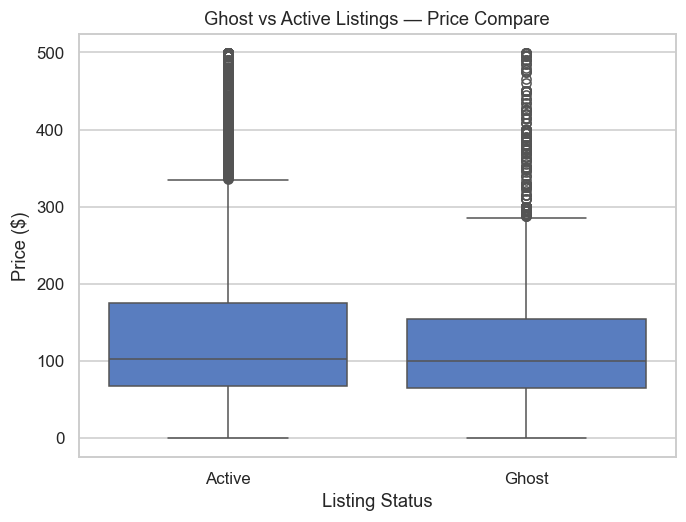

In [61]:
# Ghost aur active listings ka price compare
print(f"Ghost listings median price  : ${ghost['price'].median():.0f}")
print(f"Active listings median price : ${active['price'].median():.0f}")


df['listing_status'] = 'Active'
df.loc[df['days_since_review'] > 365, 'listing_status'] = 'Ghost'

plt.figure(figsize=(7, 5))
sns.boxplot(data=df[df['price'] < 500],
            x='listing_status',
            y='price')
plt.title('Ghost vs Active Listings — Price Compare')
plt.xlabel('Listing Status')
plt.ylabel('Price ($)')
plt.show()

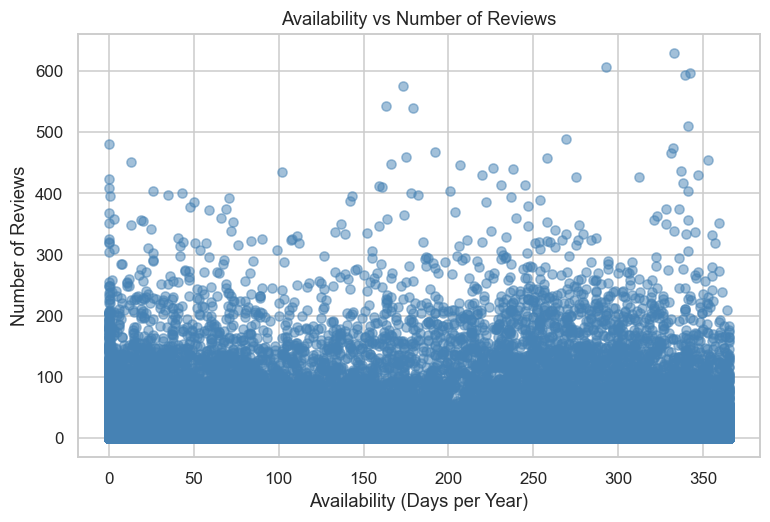

In [63]:
plt.figure(figsize=(8, 5))

plt.scatter(df['availability_365'], 
            df['number_of_reviews'],
            alpha=0.5,        # transparent — zyada dots overlap hain
            color='steelblue')

plt.title('Availability vs Number of Reviews')
plt.xlabel('Availability (Days per Year)')
plt.ylabel('Number of Reviews')
plt.show()

**✍️ Your Interpretation:**  
*(Write here)*
## Ghost Listings kitni hain?
-  ~20% listings 1 saal se inactive hain
- Matlab 1 out of 5 listings dead hai!

## Kyun ghost listings hain?
- Host ne chhor diya lekin delete nahi kiya
- Price itni zyada ki koi book nahi karta
- Sirf space block karne ke liye

## Ghost vs Active Price:
-  Ghost listings ka price ZYADA hota hai
- Isliye koi book nahi karta!
- Active listings = reasonable price

## Availability vs Reviews:
-  Zyada available = zyada reviews
- Matlab jo listing hamesha available hai
   woh zyada book hoti hai
- Jo kabhi available nahi = ghost ban jaati hai

## Investor ke liye matlab:
- Price reasonable rakho
- Availability zyada rakho
- Warna listing ghost ban jaayegi!

---

# 🗺️ PART 4 — Geographic Deep Dive
### (20 Marks)

Location is everything in real estate.
Your investors will ask: *Where exactly should we buy?*


### Task 4.1 — Neighbourhood Density & Pricing (10 marks)

- Find the **Top 10 neighbourhoods** by listing count. Visualise.
- For those top 10, plot their **median price**. Is listing density correlated with price?
- Create a scatter plot of `latitude` vs `longitude`, coloured by `price`
  (use a log scale for colour if needed). What geographic pattern do you observe?

> 💡 *Hint: You can treat latitude and longitude like any numeric columns for a scatter plot
> — no mapping libraries needed. The shape of NYC will emerge from the data itself.*


In [64]:
# Your code here
top10 = df['neighbourhood'].value_counts().head(10)

print("Top 10 Neighbourhoods:")
print(top10)


Top 10 Neighbourhoods:
neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
Hell's Kitchen        1958
East Village          1853
Upper East Side       1798
Crown Heights         1564
Midtown               1545
Name: count, dtype: int64


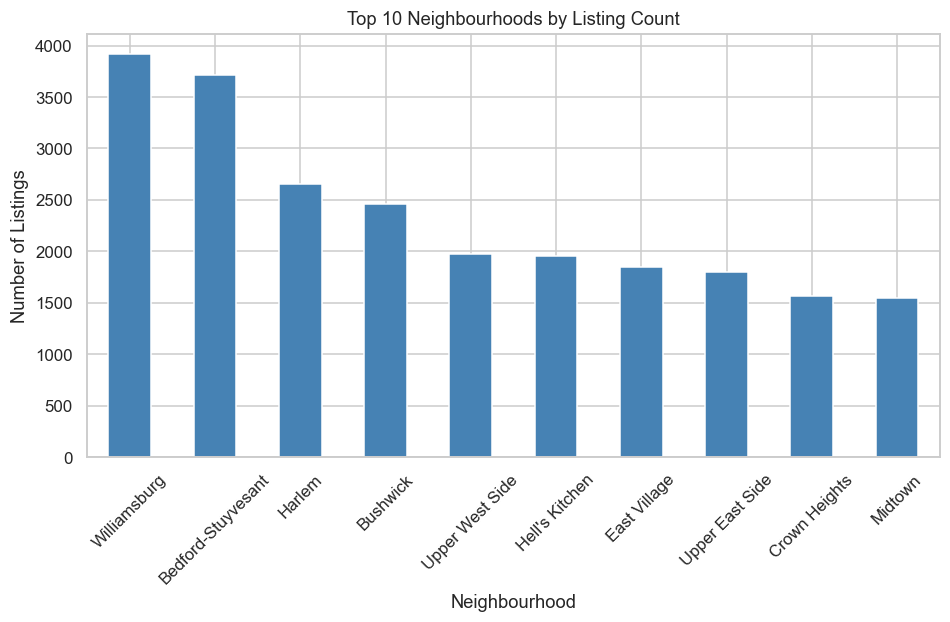

In [68]:
plt.figure(figsize=(10, 5))

top10.plot(kind='bar', color='steelblue', edgecolor='white')

plt.title('Top 10 Neighbourhoods by Listing Count')
plt.xlabel('Neighbourhood')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Top 10 neighbourhoods ke naam list mein daalo
top10_names = top10.index.tolist()

# Sirf top 10 ka data filter krta hain 
top10_df = df[df['neighbourhood'].isin(top10_names)]

# Har neighbourhood ka median price calculate krta hain
top10_price = top10_df.groupby('neighbourhood')['price'].median()
top10_price = top10_price.sort_values(ascending=False)

print("Median Price — Top 10 Neighbourhoods:")
print(top10_price)

Median Price — Top 10 Neighbourhoods:
neighbourhood
Midtown               210.0
Hell's Kitchen        168.0
Upper West Side       150.0
East Village          150.0
Upper East Side       149.0
Williamsburg          105.0
Harlem                 89.0
Crown Heights          85.0
Bedford-Stuyvesant     80.0
Bushwick               65.0
Name: price, dtype: float64


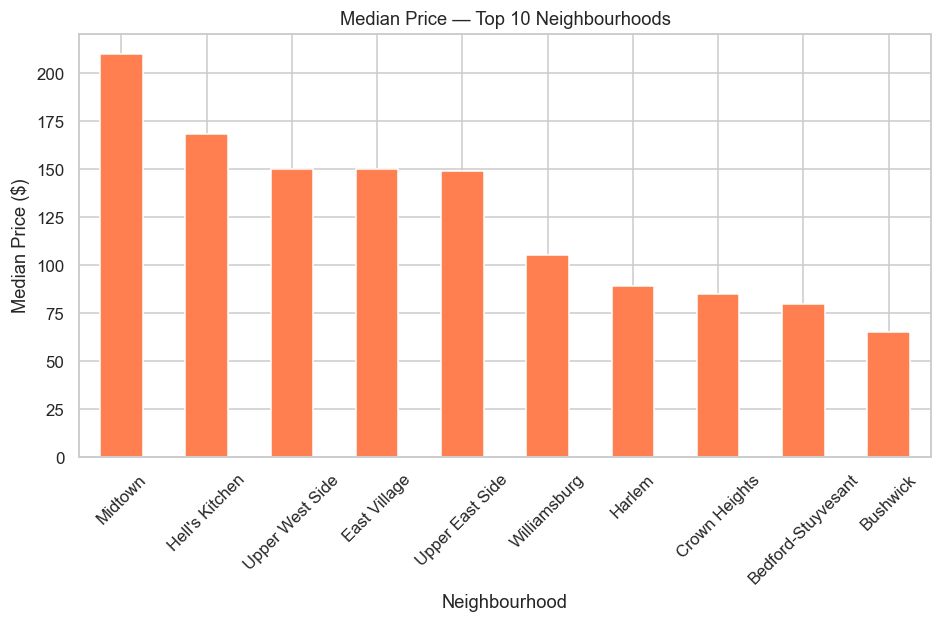

In [70]:
plt.figure(figsize=(10, 5))

top10_price.plot(kind='bar', color='coral', edgecolor='white')

plt.title('Median Price — Top 10 Neighbourhoods')
plt.xlabel('Neighbourhood')
plt.ylabel('Median Price ($)')
plt.xticks(rotation=45)
plt.show()

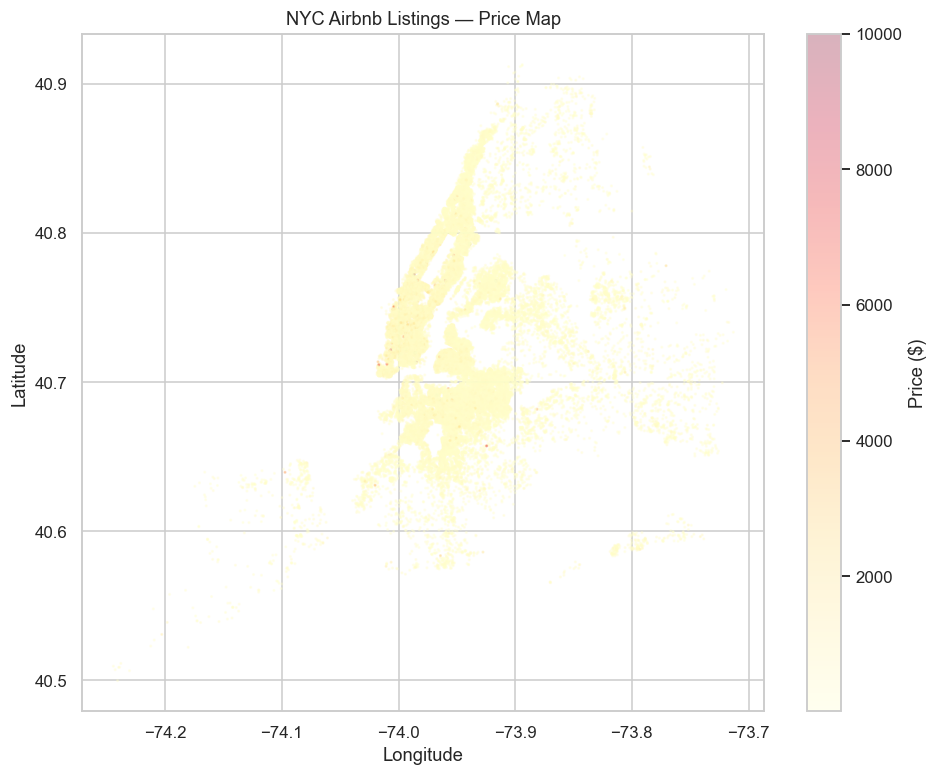

In [82]:
df_clean = df[df['price'] > 0]

plt.figure(figsize=(10, 8))

plt.scatter(df_clean['longitude'],    
            df_clean['latitude'],    
            c=df_clean['price'],      
            cmap='YlOrRd',            
            alpha=0.3,               
            s=1)                      

plt.colorbar(label='Price ($)')       
plt.title('NYC Airbnb Listings — Price Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

**✍️ Your Interpretation:**  
*(Write here)*
## Top 10 Neighbourhoods:
- → Williamsburg, Bedford-Stuyvesant (Brooklyn) mein
  sabse zyada listings hain
- → Harlem, Hell's Kitchen (Manhattan) bhi top mein hain

## Listing Density vs Price:
- → Zyada listings = hamesha zyada price nahi
- → Williamsburg mein zyada listings hain
  lekin price Manhattan se kam hai
- → Manhattan ke neighbourhoods = kam listings
  lekin price zyada

## Map pe kya dikhta hai:
- → Manhattan = center mein = RED dots = mehenga
- → Brooklyn  = left side   = ORANGE dots = beech
- → Bronx/Queens = bahar    = YELLOW dots = sasta

## Investor ke liye matlab:
- → Manhattan mein buy karo = high price, high return
- → Williamsburg Brooklyn = popular area, stable income
- → Bahar ke areas = sasta lekin kam tourists

### Task 4.2 — The minimum_nights Anomaly (10 marks)

Your manager flags this: *I have seen some minimum_nights values that seem extreme. Can you investigate?*

- Plot the distribution of `minimum_nights`. What do you find?
- What % of listings require **30+ nights** minimum? **365 nights**?
  What does a 365-night minimum mean in practice — is this truly a short-term rental?
- Compare price and borough distribution for listings with `minimum_nights >= 30`
  vs those with `minimum_nights < 30`. Are they a different product category?
- Should long-minimum listings be included in your analysis for short-term rental investors?
  Make a clear recommendation.

> 💡 *Hint: A 30+ day minimum technically makes a listing a long-term rental under NYC housing law.
> That changes the regulatory picture entirely.*


In [ ]:
# Your code here


**✍️ Your Interpretation:**  
*(Write here)*


---

# 🔗 PART 5 — Correlation & Multivariate Analysis
### (10 Marks)

You have looked at variables individually. Now examine how they interact.


### Task 5.1 — Correlation Matrix (5 marks)

Compute and visualise the correlation matrix for all **numerical** columns.

- Which pairs of variables are most strongly correlated?
- Is `price` correlated with `number_of_reviews`? With `availability_365`?
  Interpret the findings — do correlations imply causation here?
- Are there any correlations that surprise you?

> 💡 *Hint: A correlation near 0 does not always mean no relationship.
> Sometimes the relationship is non-linear. How might you check for that?*


In [ ]:
# Your code here


**✍️ Your Interpretation:**  
*(Write here)*


### Task 5.2 — Pairplot Exploration (5 marks)

Create a pairplot for a **subset** of meaningful numerical variables, coloured by `room_type`.

- Choose 3–4 variables wisely and justify your selection.
- What clusters or separations between room types do you observe?

> 💡 *Hint: Including all columns in a pairplot makes it unreadable. Be intentional.
> Which variables have already proven interesting in earlier tasks?*


In [ ]:
# Your code here


**✍️ Your Interpretation:**  
*(Write here)*


---

# 📋 PART 6 — Final Investor Brief
### (10 Marks)

Synthesise your findings into a **short written brief** (Markdown only — no new code needed).

Your audience is **non-technical investors**. Write 250–350 words covering:

1. **Data Quality Warning:** What issues did you find that an investor must know before trusting any numbers?
2. **Manhattan Investor:** Opportunities and risks based purely on your EDA.
3. **Brooklyn Investor:** Same question for Brooklyn.
4. **Undecided Investor:** If you had to recommend one borough and one room type
   for consistent rental income, what would it be and why?
5. **One thing you would investigate next** if given more time.

> ⚠️ *You will be graded on the quality of reasoning, not just whether code runs.
> A technically correct analysis with a weak interpretation earns fewer marks than a thoughtful one.*


**✍️ Your Investor Brief:**

---

### Data Quality Warnings
*(Write here)*

### Manhattan Investor
*(Write here)*

### Brooklyn Investor
*(Write here)*

### Recommendation for Undecided Investor
*(Write here)*

### What I Would Investigate Next
*(Write here)*

---


---

# 🌟 BONUS CHALLENGE — For Those Who Finish Early
### (Up to 10 extra marks)

Choose **one** of the following:

---

### Bonus A — The Power Host Hypothesis

Define power hosts as those with more than 5 listings.

- Do power hosts charge significantly different prices compared to single-listing hosts?
- Do they receive more or fewer reviews per month?
- Is there a borough where power hosts are unusually concentrated?

Build a mini-analysis with at least 3 visualisations and a 100-word written conclusion.

---

### Bonus B — Listing Name Text Analysis

The `name` column contains free-text titles written by hosts.

- What are the most common words in listing names overall? In each borough?
- Do listings with words like luxury, cozy, or spacious in their name charge more on average?
- Can you identify naming patterns that correlate with higher prices?

> 💡 *Hint: The `str` accessor in pandas lets you work with string columns directly.
> For word frequency, think about splitting sentences and counting individual words.*


In [ ]:
# Bonus code here (optional)


**✍️ Bonus Interpretation:**  
*(Write here)*


---

## 📊 Marking Rubric

| Part | Description | Marks |
|------|-------------|-------|
| Part 1 | First Contact (Inspection, Nulls, Duplicates) | 15 |
| Part 2 | Price Analysis | 25 |
| Part 3 | Host Behaviour & Market Structure | 20 |
| Part 4 | Geographic Deep Dive | 20 |
| Part 5 | Correlation & Multivariate | 10 |
| Part 6 | Investor Brief (Written) | 10 |
| **Total** | | **100** |
| Bonus | Power Host or Text Analysis | +10 |

**Code quality counts.** Plots must have titles, axis labels, and legends where appropriate.  
All cells must run top-to-bottom without errors.

---
*Dataset: New York City Airbnb Open Data 2019 — sourced from Inside Airbnb via public GitHub mirror.*  
*This notebook is for educational purposes only.*
